In [178]:
# Adult Census Income Dataset
import pandas as pd
import numpy as np
df=pd.read_csv(r'D:\OneDrive\Desktop\FullStack Data Science\Adult_Census_Income\adult.csv')
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [179]:
data=df.copy()
data.drop('fnlwgt',axis=1,inplace=True)

In [180]:
data.describe

<bound method NDFrame.describe of        age workclass     education  education.num      marital.status  \
0       90         ?       HS-grad              9             Widowed   
1       82   Private       HS-grad              9             Widowed   
2       66         ?  Some-college             10             Widowed   
3       54   Private       7th-8th              4            Divorced   
4       41   Private  Some-college             10           Separated   
...    ...       ...           ...            ...                 ...   
32556   22   Private  Some-college             10       Never-married   
32557   27   Private    Assoc-acdm             12  Married-civ-spouse   
32558   40   Private       HS-grad              9  Married-civ-spouse   
32559   58   Private       HS-grad              9             Widowed   
32560   22   Private       HS-grad              9       Never-married   

              occupation   relationship   race     sex  capital.gain  \
0                

In [181]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   education       32561 non-null  str  
 3   education.num   32561 non-null  int64
 4   marital.status  32561 non-null  str  
 5   occupation      32561 non-null  str  
 6   relationship    32561 non-null  str  
 7   race            32561 non-null  str  
 8   sex             32561 non-null  str  
 9   capital.gain    32561 non-null  int64
 10  capital.loss    32561 non-null  int64
 11  hours.per.week  32561 non-null  int64
 12  native.country  32561 non-null  str  
 13  income          32561 non-null  str  
dtypes: int64(5), str(9)
memory usage: 5.9 MB


In [182]:
data.duplicated().sum()

np.int64(3465)

In [183]:
data.drop_duplicates(inplace=True)

In [184]:
data.duplicated().sum()

np.int64(0)

In [185]:
data['workclass'].unique()

<ArrowStringArray>
[               '?',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str

In [186]:
data['workclass']=data['workclass'].replace('?','Never-worked')

In [187]:
data['education'].unique()

<ArrowStringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str

In [188]:
edu={
    'Some-college':'Dropout',
    '1st-4th':'School',
    '11th':'High-School',
    '12th':'High-School',
    '9th':'School',
    '5th-6th':'School',
    '7th-8th':'School',
    '10th':'High-School',
    'Prof-school':'Graduate',
    'Assoc-acdm':'College',
    'Assoc-voc':'College',
    'HS-grad':'High-School'
    
}
data['education']=data['education'].replace(edu) # here in place of .replace(edu), we can use .map(edu) 
# for using map(), we need all the values in that dictionary
# but for replace, we can choose any value to replacec it with.
data['education'].unique()

<ArrowStringArray>
['High-School',     'Dropout',      'School',   'Doctorate',    'Graduate',
   'Bachelors',     'Masters',     'College',   'Preschool']
Length: 9, dtype: str

In [189]:
data['marital.status'].unique()

<ArrowStringArray>
[              'Widowed',              'Divorced',             'Separated',
         'Never-married',    'Married-civ-spouse', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str

In [190]:
data['marital.status']=data['marital.status'].replace({'Married-civ-spouse':'Married','Married-spouse-absent':'Married','Married-AF-spouse':'Married','Never-married':'Single'})
data['marital.status'].unique()

<ArrowStringArray>
['Widowed', 'Divorced', 'Separated', 'Single', 'Married']
Length: 5, dtype: str

In [191]:
data['occupation'].unique()

<ArrowStringArray>
[                '?',   'Exec-managerial', 'Machine-op-inspct',
    'Prof-specialty',     'Other-service',      'Adm-clerical',
      'Craft-repair',  'Transport-moving', 'Handlers-cleaners',
             'Sales',   'Farming-fishing',      'Tech-support',
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

In [192]:
data['occupation']=data['occupation'].replace('?','Jobless')
data['occupation'].unique()

<ArrowStringArray>
[          'Jobless',   'Exec-managerial', 'Machine-op-inspct',
    'Prof-specialty',     'Other-service',      'Adm-clerical',
      'Craft-repair',  'Transport-moving', 'Handlers-cleaners',
             'Sales',   'Farming-fishing',      'Tech-support',
   'Protective-serv',      'Armed-Forces',   'Priv-house-serv']
Length: 15, dtype: str

In [193]:
data['relationship'].unique()

<ArrowStringArray>
['Not-in-family', 'Unmarried', 'Own-child', 'Other-relative', 'Husband',
 'Wife']
Length: 6, dtype: str

In [194]:
data['income'].unique()

<ArrowStringArray>
['<=50K', '>50K']
Length: 2, dtype: str

In [195]:
data.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Never-worked,High-School,9,Widowed,Jobless,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,High-School,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Never-worked,Dropout,10,Widowed,Jobless,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,School,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Dropout,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [196]:
data.isna().sum()

age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [197]:
data.duplicated().sum()

np.int64(6)

In [198]:
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='income', ylabel='count'>

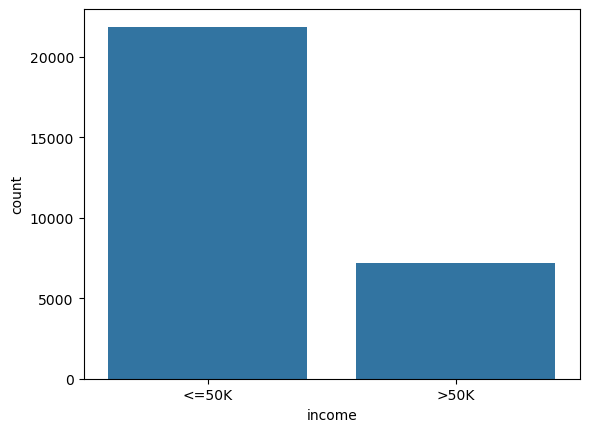

In [199]:
# EDA 
#How many people earn >50K and <=50K?
# we can visualize this using a count plot.
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(data,x='income')

Conclusion:
-----------
Above 20,000 people are earning less than 50,000 dollars of income.
only approx 7-8 thousand people are earning more than 50,000 dollars of income

<Axes: xlabel='income', ylabel='count'>

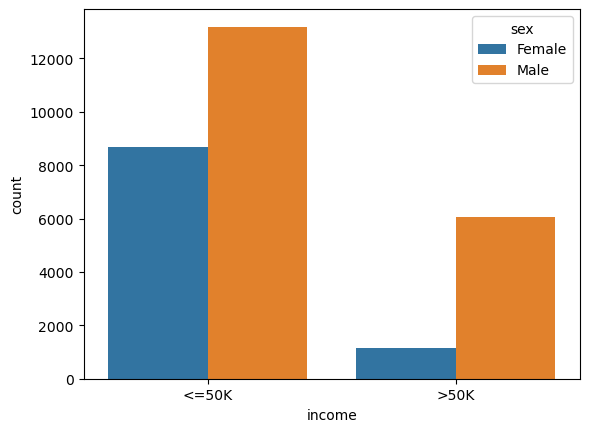

In [200]:
sns.countplot(data,x='income',hue='sex')

In [201]:
data.shape

(29090, 14)

In [202]:
# What percentage of people earn more than $50K?
percent=(7000/29090)*100
print(percent)

24.06325197662427


Conclusion:
-----------
only 24% of the population are earning more than 50k$

<Axes: xlabel='age', ylabel='Count'>

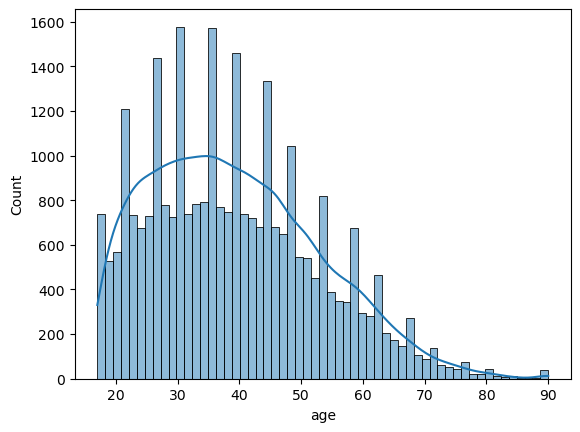

In [203]:
# What is the age distribution of the people?
sns.histplot(data,x='age',kde=True)

Conclusion
------------
As this is the right skewed graph, outliers are in the right side. 
that means, age people who are still earning are less. 
only people aged between 30-40 are earning more than other aged people.

<Axes: xlabel='income', ylabel='age'>

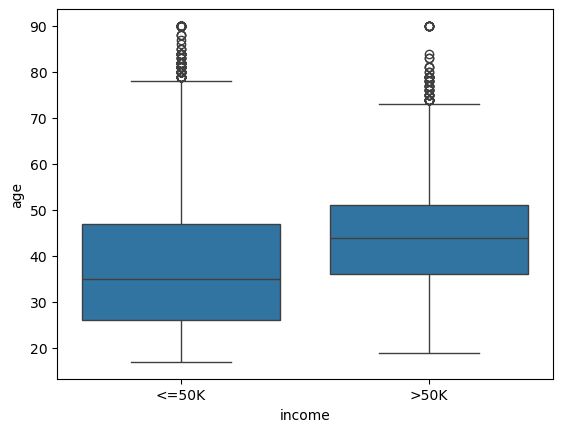

In [204]:
# does age influence income?
sns.boxplot(data=data, x='income', y='age')
# we can also use countplot for this.

Conclusion
----------
yes. age influence income. 
Here in the graph, people with age 28-47, earns <=50k $ but,
people with age around 37-51 earns >50k. 
so, we can say that there might be a chance of earning high income for aged people.

In [205]:
data.head(2)

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Never-worked,High-School,9,Widowed,Jobless,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,High-School,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K


<Axes: xlabel='income', ylabel='count'>

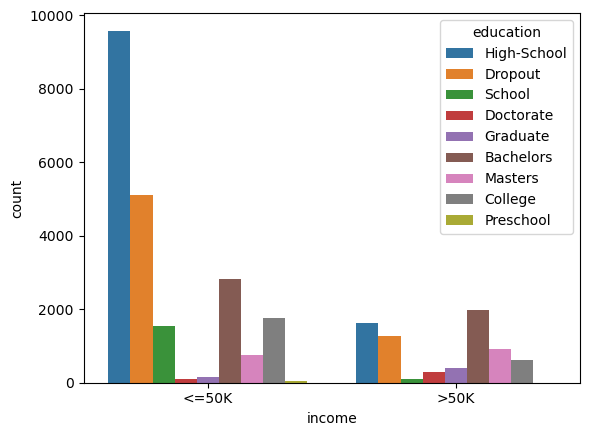

In [206]:
# Which education level has the highest percentage of people earning >50K?
sns.countplot(data,x='income',hue='education')

Conclusion:
-------------
most of the people with Bachelors degree are earning >50k. 
But people who are earning <50k are most likely high-school students


In [207]:
# Which occupation has the highest percentage of high-income earners?
# data[data['income']=='>50k'].groupby('occupation').value_counts().sort_values(ascending=False)
data[data['income'] == '>50K'].groupby('occupation').size().sort_values(ascending=False)

occupation
Exec-managerial      1773
Prof-specialty       1746
Sales                 903
Craft-repair          777
Adm-clerical          484
Transport-moving      303
Tech-support          269
Machine-op-inspct     228
Protective-serv       203
Jobless               189
Other-service         136
Farming-fishing       114
Handlers-cleaners      81
Armed-Forces            1
Priv-house-serv         1
dtype: int64

Conclusion:
-----------
the occupation, Exec-Managerial is earning >50k 

In [208]:
# Which workclass has the highest proportion(percentage) of people earning >50K?
data.groupby('workclass')['income'].value_counts(normalize=True).mul(100).unstack()['>50K'].sort_values(ascending=False)
# value_counts() -> gives the count of each row 
# value_counts(normalize=True) -> gives the fraction like sales/total.of outcomes 
# unstack() -> used to seperate <50k and >50k in to individual columns. 

workclass
Self-emp-inc        55.453712
Federal-gov         38.266385
Local-gov           29.460784
Self-emp-not-inc    28.629195
State-gov           27.358491
Private             22.404037
Never-worked        11.545510
Without-pay               NaN
Name: >50K, dtype: float64

Easy trick to remember
.sum() → Add values.
.value_counts() → Count unique values in a column.
.size() → Count rows in each group.

In [209]:
# Do people who work more hours per week tend to earn >50K?
data.groupby('hours.per.week')['income'].value_counts().unstack()['>50K'].sort_values(ascending=False)

hours.per.week
40    2815.0
50    1168.0
45     642.0
60     616.0
55     313.0
       ...  
87       NaN
88       NaN
91       NaN
92       NaN
94       NaN
Name: >50K, Length: 94, dtype: float64

Conclusion:
-------------
more working hours is not equal to more income

<Axes: xlabel='capital.loss', ylabel='Count'>

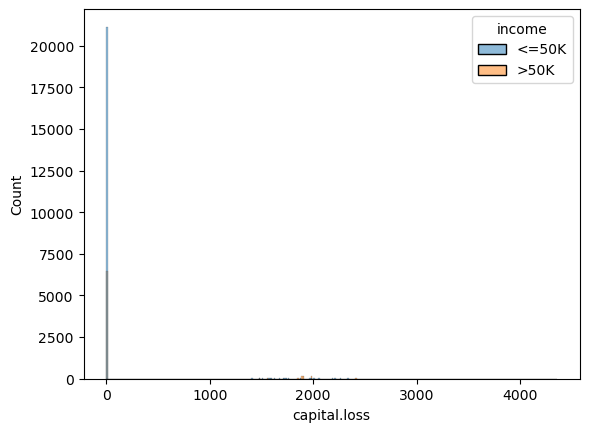

In [210]:
# Is there any relationship between capital loss and income?
sns.histplot(data,x='capital.loss',hue='income')

In [211]:
data['capital.loss'].value_counts()

capital.loss
0       27579
1902      202
1977      166
1887      157
1485       51
        ...  
1944        1
1844        1
1539        1
1411        1
155         1
Name: count, Length: 92, dtype: int64

Conclusion:
-------------
Most of the people does not having capital loss. that means, capital loss=0
so, there is no relationship between capital loss and income

In [212]:
# Which race has the highest percentage of high-income earners?
data.groupby('race')['income'].value_counts(normalize=True).mul(100).sort_values(ascending=False).unstack()['>50K']

race
Amer-Indian-Eskimo    11.575563
Asian-Pac-Islander    26.589595
Black                 12.639895
Other                  9.225092
White                 26.551244
Name: >50K, dtype: float64

Conclusion:
-----------
from the above analysis, we can confidently say that Amer-Indian-Eskimo people are high in percentage of earning >50k


In [213]:
data.head(2)

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Never-worked,High-School,9,Widowed,Jobless,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,High-School,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K


In [214]:
# Which native country of people earning >50K?
data['native.country'].unique()
data['native.country']=data['native.country'].replace('?','Unknown_country')

In [215]:

data.groupby('native.country')['income'].value_counts().unstack()['>50K'].sort_values(ascending=False)

native.country
United-States                 6539.0
Unknown_country                145.0
Philippines                     61.0
Germany                         44.0
India                           40.0
Canada                          39.0
Mexico                          33.0
England                         30.0
Cuba                            25.0
Italy                           25.0
Japan                           24.0
Taiwan                          20.0
China                           20.0
Iran                            18.0
South                           16.0
Poland                          12.0
France                          12.0
Puerto-Rico                     12.0
Jamaica                         10.0
El-Salvador                      9.0
Greece                           8.0
Cambodia                         7.0
Hong                             6.0
Yugoslavia                       6.0
Ireland                          5.0
Vietnam                          5.0
Ecuador                

Conclusion:
------------
United States people are earning high income >50K compared to other countries.

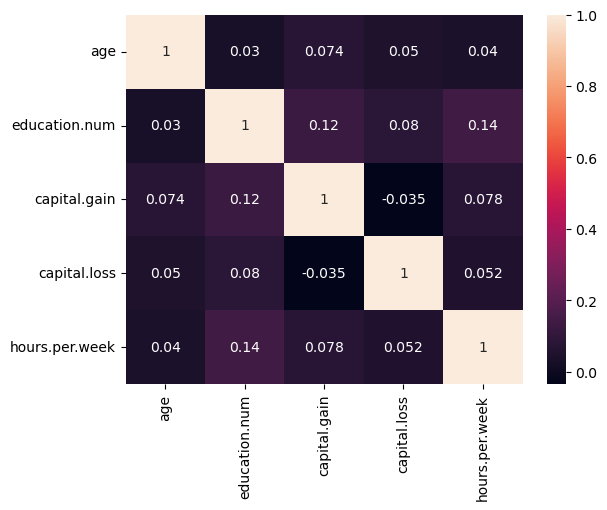

In [216]:
# Which numerical features are highly correlated?
numeric_features=data.select_dtypes(include='number')
corr=numeric_features.corr()
sns.heatmap(corr,annot=True)
plt.show()

In [217]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,accuracy_score

In [218]:
data.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Never-worked,High-School,9,Widowed,Jobless,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,High-School,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Never-worked,Dropout,10,Widowed,Jobless,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,School,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Dropout,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [219]:
# splitting the data in to features and target
x=data.drop('income',axis=1)
y=data['income']
print(x.shape,y.shape)

(29090, 13) (29090,)


In [220]:

"""Analysis.ipynbfrom sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
x=pd.get_dummies(x,drop_first=True) # drop first removes the dummy columns
# x contains numeric and category columns. if we apply onehot encoding on x, numeric columns remains unchanged except categorical columns.
le=LabelEncoder()
y=le.fit_transform(y) 
"""

'Analysis.ipynbfrom sklearn.preprocessing import OneHotEncoder\nfrom sklearn.preprocessing import LabelEncoder\nx=pd.get_dummies(x,drop_first=True) # drop first removes the dummy columns\n# x contains numeric and category columns. if we apply onehot encoding on x, numeric columns remains unchanged except categorical columns.\nle=LabelEncoder()\ny=le.fit_transform(y) \n'

In [221]:
# we can use onehot encoding for categorical features. 
# using onehot encoding requires columns.pkl to use in the streamlit.py 
# but, using pipeline makes much easier with out any mess
# columns.pkl is not only for randomforest but for all caltegorical feature columns. 
# if the data contains all numeric columns, we can directly give own values for prediction 
# but if the data is having categorical columns, we must use column.pkl which contains all categoricla column names and this pkl file is used in streamlit.

In [222]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [223]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [224]:
data.columns

Index(['age', 'workclass', 'education', 'education.num', 'marital.status',
       'occupation', 'relationship', 'race', 'sex', 'capital.gain',
       'capital.loss', 'hours.per.week', 'native.country', 'income'],
      dtype='str')

In [225]:
category_features = [
    'workclass', 'education', 'marital.status', 'occupation',
    'relationship', 'race', 'sex', 'native.country'
]

numeric_features = [
    'age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), category_features),
        ('num', 'passthrough', numeric_features)
    ]
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,   # try increasing for stability
        max_depth=10,
        min_samples_split=2,
        random_state=42
    ))
])

pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['workclass', 'education',
                                                   'marital.status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native.country']),
                                                 ('num', 'passthrough',
                                                  ['age', 'education.num',
                                                   'capital.gain',
                                                   'capital.loss',
                                                   'hours.per.week'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, random_state=42))])

In [226]:
prediction = pipeline.predict(x_test)
print("F1 Score:", f1_score(y_test, prediction,pos_label='>50K')) # pos_label -> indicates the positiv elabel to consider as 1.
print("Accuracy score:",accuracy_score(y_test,prediction))

F1 Score: 0.6348547717842323
Accuracy score: 0.8487452732897903


In [227]:
import joblib
joblib.dump(pipeline,'adult_census_income.pkl')

['adult_census_income.pkl']